In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

plt.style.use('default')

In [2]:
df = pd.read_csv('../data/raw_analyst_ratings.csv')

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
df.shape

(1407328, 6)

In [4]:
df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [6]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

# Exploratory Data Analysis

This notebook explores the financial news dataset to identify:
- textual patterns
- publisher activity
- publication trends
- recurring financial themes

In [7]:
df['headline_length'] = df['headline'].apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

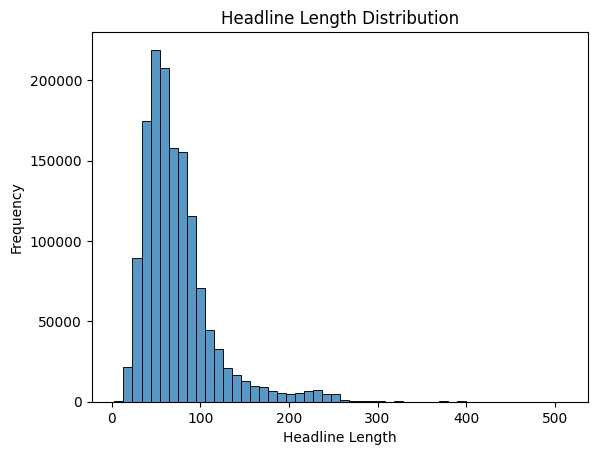

In [8]:
sns.histplot(df['headline_length'], bins=50)

plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

### Insight

The distribution of headline lengths is right-skewed, with most headlines ranging between approximately 40 and 100 characters. This suggests that financial news headlines are generally concise and optimized for quick communication of market-relevant information.

A smaller number of unusually long headlines appear as outliers, potentially reflecting more detailed or multi-part announcements.

In [9]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

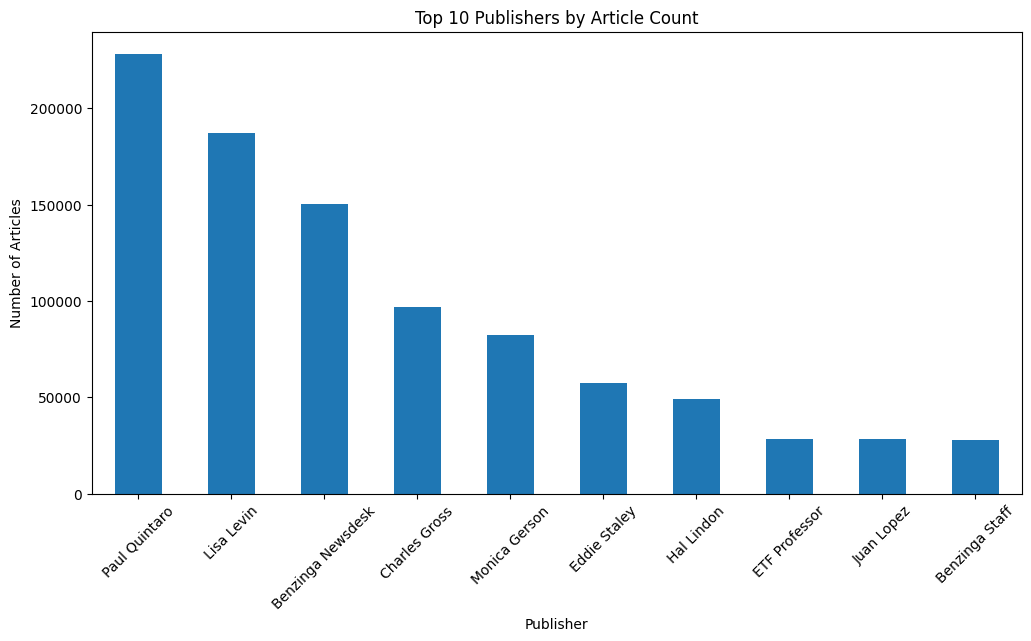

In [11]:
plt.figure(figsize=(12,6))

publisher_counts.head(10).plot(kind='bar')

plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

### Publisher Activity Insight

The dataset is heavily concentrated among a small number of publishers. Paul Quintaro and Lisa Levin alone contribute a substantial share of the total financial news articles.

This suggests that the dataset may reflect the editorial style and reporting focus of a limited number of contributors, potentially introducing source bias into sentiment analysis results.

Additionally, the strong presence of Benzinga-affiliated publishers indicates that the dataset is largely centered around financial market reporting and trading-oriented news coverage.

In [17]:
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)

df['date'].head()

0   2020-06-05 14:30:54+00:00
1   2020-06-03 14:45:20+00:00
2   2020-05-26 08:30:07+00:00
3   2020-05-22 16:45:06+00:00
4   2020-05-22 15:38:59+00:00
Name: date, dtype: datetime64[us, UTC]

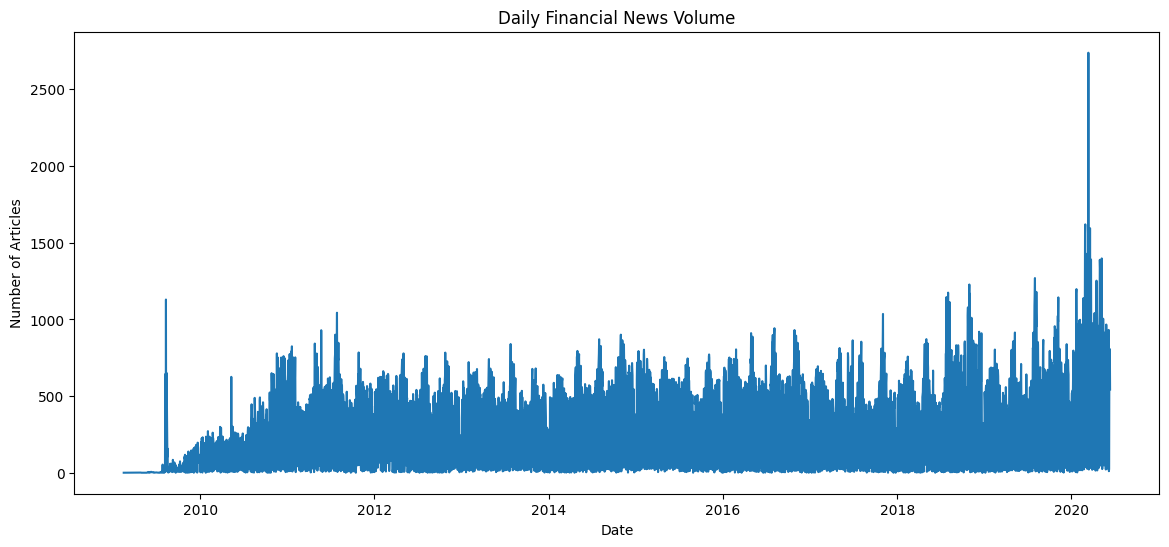

In [19]:
daily_news = df.groupby(df['date'].dt.date).size()


plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily Financial News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [21]:
df['hour'] = df['date'].dt.hour

df['hour'].value_counts().sort_index()

hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
Name: count, dtype: int64

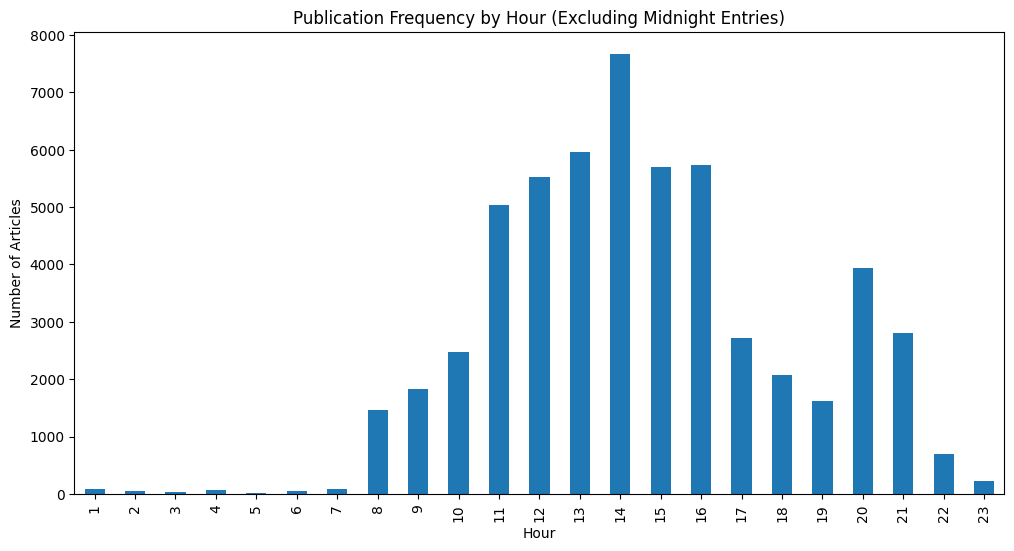

In [25]:
plt.figure(figsize=(12,6))
non_midnight = df[df['hour'] != 0]
non_midnight['hour'].value_counts().sort_index().plot(kind='bar')

plt.title("Publication Frequency by Hour (Excluding Midnight Entries)")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")

plt.show()

### Publishing Time Insight

A very large proportion of articles appear at hour 0 (midnight), suggesting that many records contain date-only timestamps without precise publication times.

This indicates incomplete temporal granularity within the dataset and may limit fine-grained intraday analysis of news publication behavior.

In [26]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

In [27]:
X = vectorizer.fit_transform(df['headline'])

In [28]:
words = vectorizer.get_feature_names_out()

words

array(['announces', 'benzinga', 'buy', 'downgrades', 'earnings', 'eps',
       'est', 'market', 'mid', 'price', 'pt', 'raises', 'reports',
       'sales', 'shares', 'stocks', 'trading', 'update', 'vs', 'week'],
      dtype=object)

In [29]:
counts = np.asarray(X.sum(axis=0)).flatten()

In [30]:
word_freq = pd.DataFrame({
    'word': words,
    'count': counts
})

In [31]:
word_freq = word_freq.sort_values(
    by='count',
    ascending=False
)

word_freq

,word,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


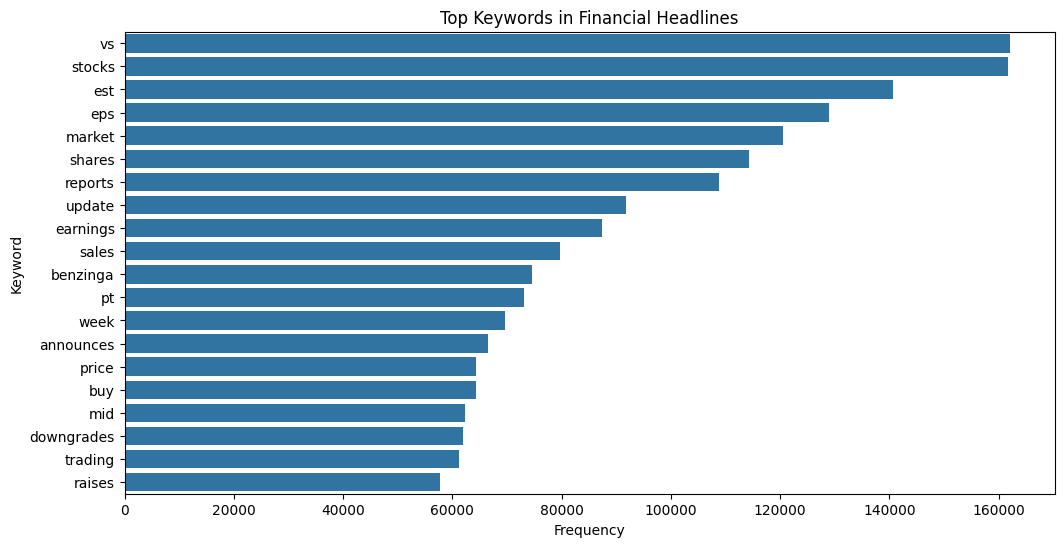

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=word_freq,
    x='count',
    y='word'
)

plt.title("Top Keywords in Financial Headlines")
plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.show()

### Keyword Analysis Insight

The keyword analysis reveals that the dataset is strongly focused on stock market performance, analyst recommendations, earnings reports, and trading activity.

Frequently occurring terms such as "stocks", "market", "earnings", "price", and "buy" indicate that the headlines primarily target investors and market participants.

Several abbreviated financial terms such as "eps", "pt", and "est" also appear frequently, reflecting the specialized language commonly used in financial journalism and analyst reporting.